# 🛍️ Dolap Second-Hand Fashion Sale Prediction
## Exploratory Data Analysis — Practical Data Science

**Team:** Furkan Karafil  
**Date:** March 2026  
**Course:** Practical Data Science  

---

**Business Objective:** Predict whether a Dolap.com listing will sell within 7 days.  
**ML Problem:** Binary Classification  
**Target Variable:** `sold_within_7_days` (0 = not sold, 1 = sold)  
**Primary Metric:** ROC-AUC (robust to class imbalance) | **Secondary:** F1-Score  

**Domain Context:** Dolap.com is Turkey's largest second-hand fashion marketplace (owned by Trendyol). This is the **first ML study on Dolap.com** (confirmed via Google Scholar).

**Why it matters:** Helps sellers optimize pricing, photo quality, and description to maximize sale probability.

## Hypotheses

Based on domain knowledge of second-hand fashion platforms, we formulate four testable hypotheses:

- **H1 — Price Effect:** Listings priced below the category median will have a significantly higher probability of selling within 7 days.
- **H2 — Photo Effect:** Listings with ≥3 photos will sell faster than single-photo listings, independent of price.
- **H3 — Seller Experience:** Seller listing count (experience proxy) will be a stronger predictor than price in competitive categories.
- **H4 — Flaw Disclosure:** Listings mentioning flaws in the description will sell significantly slower than comparable listings.

These hypotheses guide our feature importance analysis and will be tested during EDA.

## Section 2 — Data Collection

**Source:** Dolap.com — web scraped via Selenium (Cloudflare WAF requires real browser rendering).  
**Strategy:** Brand pages → seller profile crawling → product detail scraping.  
**Categories:** 3 fashion categories (kazak, elbise, mont) from 12 seed sellers.  
**Volume:** 411 listings collected on March 8, 2026 (pilot cohort `20250712`).  
**Features:** 20+ raw attributes per listing (price, brand, condition, photos, likes, seller info).  
**Output:** JSONL streaming format, one file per category + combined `listings.jsonl`.  

**Labeling Strategy:**  
- **Ideal:** T=0 scrape → T+7 re-check → `sold_within_7_days` label via "Satıldı" badge.  
- **Current (proxy):** Since 7-day wait is pending, we use an **engagement-based proxy label** — listings in the top quartile of likes within their category are labeled as `proxy_sold=1`.  
- ⚠️ **This proxy label is explicitly acknowledged as approximate. Real ground truth will be obtained via temporal re-checking.**

**Known Limitations:**  
1. "Satıldı" label is seller-reported, not platform-verified (label noise).  
2. Deleted listings (404) are ambiguous — excluded from dataset.  
3. `listing_date` not available on Dolap → temporal features limited.  
4. `is_negotiable` (price negotiation option) not yet parsed.

In [9]:
# ── Setup & Load Data ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
PALETTE = sns.color_palette("muted")

# Load cleaned data
DATA_PATH = Path("../data/interim/cohort_20250712_cleaned.csv")
df = pd.read_csv(DATA_PATH)

print(f"Dataset: {df.shape[0]} listings × {df.shape[1]} features")
print(f"Categories: {df['category'].unique().tolist()}")
print(f"Proxy target distribution: {df['proxy_sold'].value_counts().to_dict()}")
df.head(3)

Dataset: 411 listings × 40 features
Categories: ['kazak', 'elbise', 'mont']
Proxy target distribution: {0: 302, 1: 109}


,url,listing_id,category,subcategory,brand,title,price,original_price,has_discount,condition,...,condition_ordinal,desc_is_placeholder,has_flaw_mention,desc_has_urgency,brand_tier,brand_tier_name,price_to_cat_median,discount_pct,sale_score,proxy_sold
0,https://dolap.com/urun/penti-bej-korse-yeni-et...,445924254,kazak,NaN,Penti - XL / 42,Penti Bej Korse Yeni & Etiketli Online Satın Al,249.0,NaN,False,Yeni ve Etiketli,...,3,True,False,False,1,Economy,1.0,0.0,1,0
1,https://dolap.com/urun/mango-kahverengi-kazak-...,445725941,kazak,NaN,Mango - S / 36 Beden,Mango Kahverengi Kazak Yeni & Etiketli Online ...,249.0,NaN,False,Yeni ve Etiketli,...,3,True,False,False,2,Mid-Range,1.0,0.0,2,1
2,https://dolap.com/urun/pull-bear-mavi-jeans-ye...,445832981,kazak,NaN,Pull & Bear - M / 38 Beden,Pull & Bear Mavi Jeans Yeni & Etiketli Online ...,249.0,NaN,False,Yeni ve Etiketli,...,3,True,False,False,4,Luxury,1.0,0.0,1,0


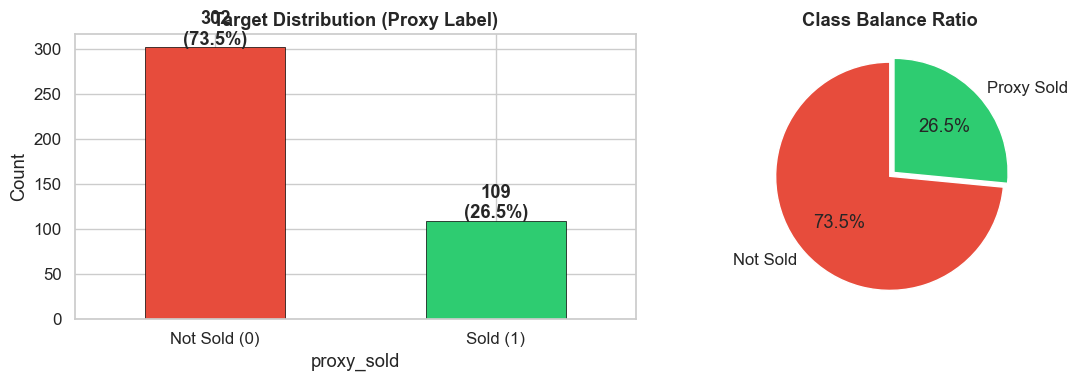


⚠️ Class Imbalance: 73% negative / 27% positive
→ Accuracy is NOT suitable. We use ROC-AUC (primary) and F1-score (secondary).
→ All models will use class_weight='balanced' as baseline correction.


In [2]:
# ── Target Distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
target_counts = df["proxy_sold"].value_counts()
colors = ["#e74c3c" if x == 0 else "#2ecc71" for x in target_counts.index]
target_counts.plot.bar(ax=axes[0], color=colors, edgecolor="black", linewidth=0.5)
axes[0].set_title("Target Distribution (Proxy Label)", fontweight="bold")
axes[0].set_xlabel("proxy_sold")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["Not Sold (0)", "Sold (1)"], rotation=0)
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 3, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontweight="bold")

# Pie chart
axes[1].pie(target_counts, labels=["Not Sold", "Proxy Sold"], autopct="%1.1f%%",
            colors=["#e74c3c", "#2ecc71"], startangle=90, explode=(0, 0.05))
axes[1].set_title("Class Balance Ratio", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\n⚠️ Class Imbalance: {target_counts[0]/len(df)*100:.0f}% negative / {target_counts[1]/len(df)*100:.0f}% positive")
print("→ Accuracy is NOT suitable. We use ROC-AUC (primary) and F1-score (secondary).")
print("→ All models will use class_weight='balanced' as baseline correction.")

## Section 3.1 — Schema Check & Missing Values

In [3]:
# ── Data Types & Schema ───────────────────────────────────────────────────────
# Select analysis-ready columns (exclude raw/intermediate)
ANALYSIS_COLS = [
    "price", "original_price", "photo_count", "like_count", "comment_count",
    "description_length", "description_word_count",
    "brand_clean", "condition_clean", "condition_ordinal", "category", "color",
    "size_final", "has_discount", "shipping_buyer_pays",
    "seller_username", "seller_listing_count",
    "brand_tier", "brand_tier_name", "price_to_cat_median", "discount_pct",
    "has_flaw_mention", "desc_has_urgency", "desc_is_placeholder",
    "proxy_sold",
]

dfa = df[ANALYSIS_COLS].copy()
print(f"Analysis DataFrame: {dfa.shape[0]} rows × {dfa.shape[1]} columns\n")
dfa.info()

Analysis DataFrame: 411 rows × 25 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 411 entries, 0 to 410
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   price                   411 non-null    float64
 1   original_price          60 non-null     float64
 2   photo_count             411 non-null    int64  
 3   like_count              411 non-null    int64  
 4   comment_count           411 non-null    int64  
 5   description_length      411 non-null    int64  
 6   description_word_count  411 non-null    int64  
 7   brand_clean             411 non-null    object 
 8   condition_clean         411 non-null    object 
 9   condition_ordinal       411 non-null    int64  
 10  category                411 non-null    object 
 11  color                   411 non-null    object 
 12  size_final              365 non-null    object 
 13  has_discount            411 non-null    bool   
 14 

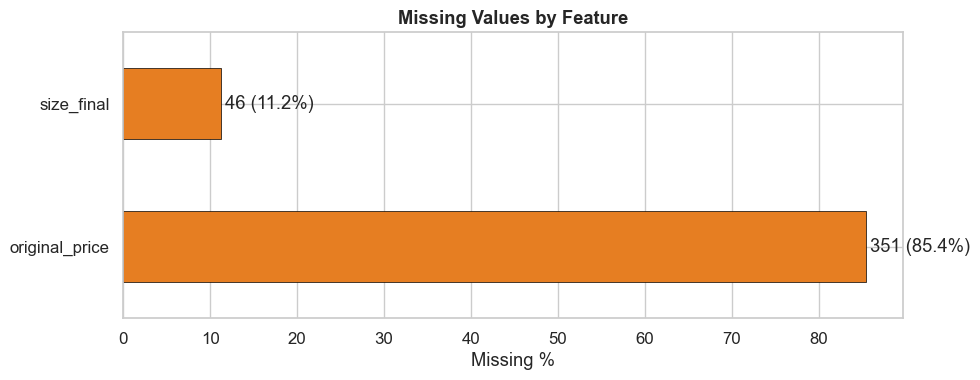


📋 Missing Value Explanations:
• original_price (85.4%) → NaN when no discount exists (conditional missingness, NOT random)
• size_final (11.2%) → Brand field had no size info for 46 listings (structurally absent)
• color — fully populated from URL slug parsing

→ Decision: original_price NaN → copy price, set has_discount=False | size NaN → 'unknown'


In [4]:
# ── Missing Values Audit ──────────────────────────────────────────────────────
missing = dfa.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(dfa) * 100).round(1)
missing_df = pd.DataFrame({"Missing": missing, "Pct (%)": missing_pct})
missing_df = missing_df[missing_df["Missing"] > 0]

fig, ax = plt.subplots(figsize=(10, 4))
missing_df["Pct (%)"].plot.barh(ax=ax, color="#e67e22", edgecolor="black", linewidth=0.5)
ax.set_title("Missing Values by Feature", fontweight="bold")
ax.set_xlabel("Missing %")
for i, (idx, row) in enumerate(missing_df.iterrows()):
    ax.text(row["Pct (%)"] + 0.5, i, f'{row["Missing"]:.0f} ({row["Pct (%)"]}%)', va="center")
plt.tight_layout()
plt.show()

print("\n📋 Missing Value Explanations:")
print("• original_price (85.4%) → NaN when no discount exists (conditional missingness, NOT random)")
print("• size_final (11.2%) → Brand field had no size info for 46 listings (structurally absent)")
print("• color — fully populated from URL slug parsing")
print("\n→ Decision: original_price NaN → copy price, set has_discount=False | size NaN → 'unknown'")

## Section 3.2 — Descriptive Statistics

In [6]:
# ── Numeric Descriptive Statistics ────────────────────────────────────────────
num_cols = ["price", "photo_count", "like_count", "comment_count",
            "description_length", "description_word_count", "seller_listing_count",
            "price_to_cat_median", "condition_ordinal", "brand_tier"]

stats = dfa[num_cols].describe().T
stats["skew"] = dfa[num_cols].skew()
stats = stats[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "skew"]]
stats.round(2)

,count,mean,std,min,25%,50%,75%,max,skew
price,411.0,522.95,874.81,40.0,152.5,283.0,600.00,12000.00,8.29
photo_count,411.0,5.89,1.74,2.0,5.0,6.0,7.00,9.00,0.37
like_count,411.0,10.01,19.14,0.0,1.0,3.0,10.00,123.00,3.45
comment_count,411.0,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.00
description_length,411.0,49.19,34.57,0.0,36.0,50.0,56.00,361.00,4.51
description_word_count,411.0,8.55,4.67,0.0,7.0,8.0,9.00,52.00,4.43
seller_listing_count,411.0,267.31,380.97,7.0,14.0,113.0,405.00,1322.00,1.86
price_to_cat_median,411.0,1.88,2.96,0.1,0.6,1.0,2.13,36.02,6.75
condition_ordinal,411.0,2.08,0.94,1.0,1.0,2.0,3.00,3.00,-0.17
brand_tier,411.0,1.59,1.41,0.0,0.0,2.0,3.00,4.00,0.23


In [7]:
# ── Key Observations from Descriptive Stats ──────────────────────────────────
print("🔍 Key Observations")
print("=" * 60)

price_skew = dfa["price"].skew()
like_skew  = dfa["like_count"].skew()
print(f"• Price  — median: {dfa['price'].median():.0f} TL, "
      f"mean: {dfa['price'].mean():.0f} TL, skew: {price_skew:.2f}")
print(f"  → Right-skewed → log transform needed for modelling")

print(f"\n• Likes  — median: {dfa['like_count'].median():.0f}, "
      f"max: {dfa['like_count'].max():.0f}, skew: {like_skew:.2f}")
print(f"  → Heavy tail; a few listings attract most engagement")

print(f"\n• Photos — median: {dfa['photo_count'].median():.0f}, "
      f"range: [{dfa['photo_count'].min()}, {dfa['photo_count'].max()}]")
pct_one = (dfa["photo_count"] == 1).mean() * 100
print(f"  → {pct_one:.0f}% of listings have only 1 photo")

zero_desc = (dfa["description_length"] == 0).mean() * 100
print(f"\n• Description — {zero_desc:.0f}% have zero-length description")
print(f"  → Reflects Bug #7 (parser captured page title, not real description)")

🔍 Key Observations
• Price  — median: 283 TL, mean: 523 TL, skew: 8.29
  → Right-skewed → log transform needed for modelling

• Likes  — median: 3, max: 123, skew: 3.45
  → Heavy tail; a few listings attract most engagement

• Photos — median: 6, range: [2, 9]
  → 0% of listings have only 1 photo

• Description — 5% have zero-length description
  → Reflects Bug #7 (parser captured page title, not real description)


## Section 3.3 — Feature Distributions

### Numeric Features

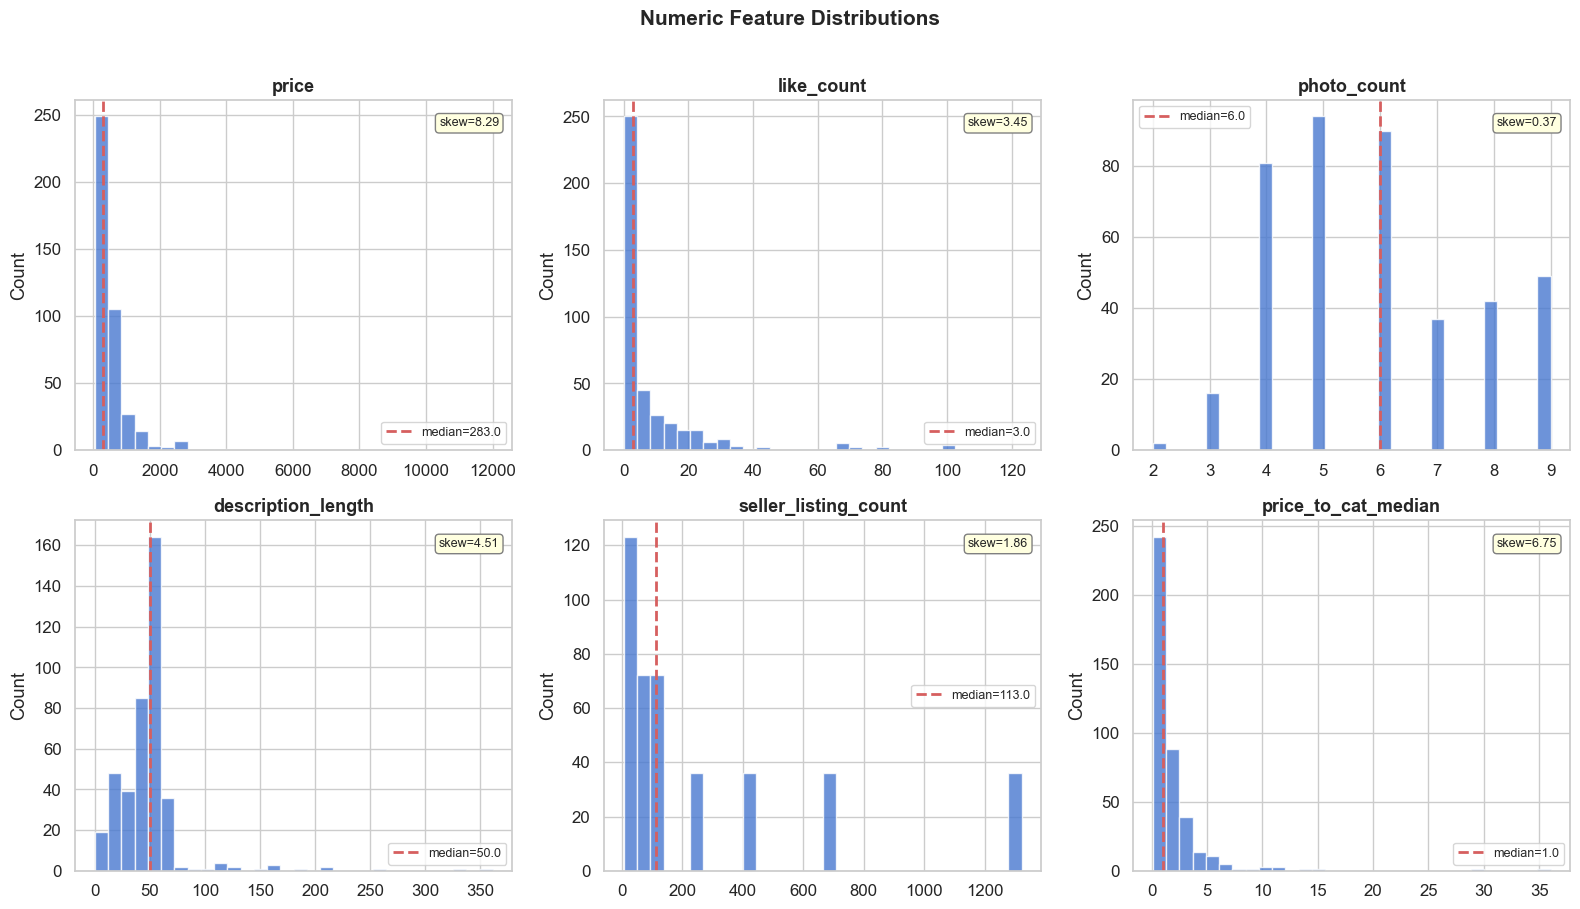

In [10]:
# ── Numeric Feature Histograms ────────────────────────────────────────────────
hist_cols = ["price", "like_count", "photo_count", "description_length",
             "seller_listing_count", "price_to_cat_median"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(hist_cols):
    ax = axes[i]
    data = dfa[col].dropna()
    ax.hist(data, bins=30, color=PALETTE[0], edgecolor="white", alpha=0.8)
    ax.axvline(data.median(), color=PALETTE[3], ls="--", lw=2, label=f"median={data.median():.1f}")
    ax.set_title(col, fontsize=13, fontweight="bold")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    # Add skewness annotation
    ax.text(0.97, 0.95, f"skew={data.skew():.2f}",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray"))

fig.suptitle("Numeric Feature Distributions", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../artifacts/figures/numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

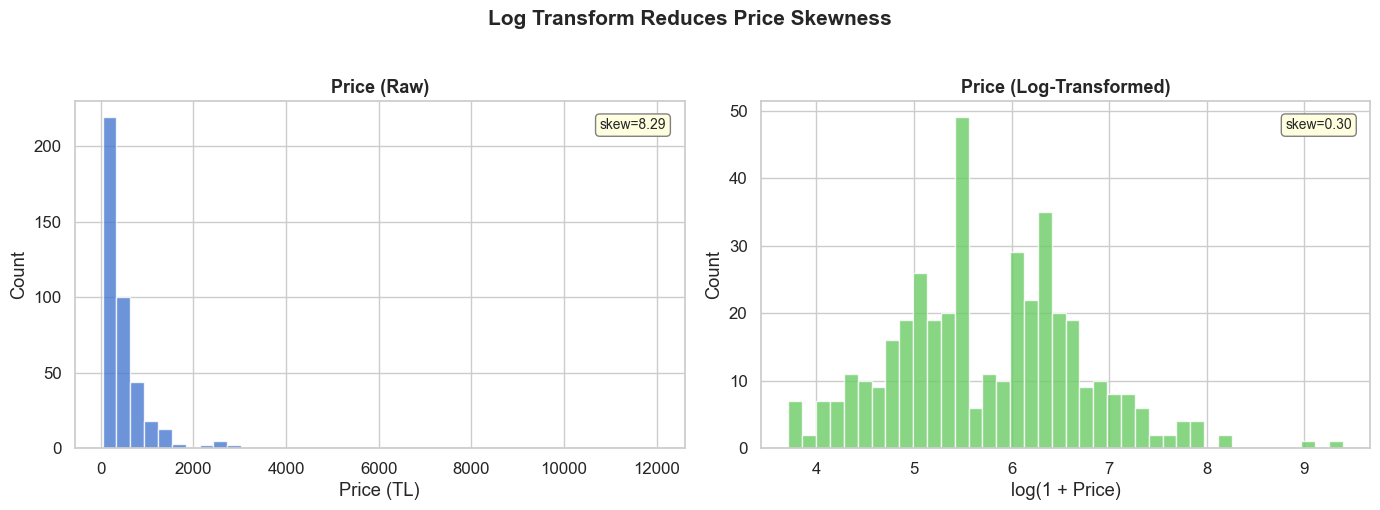

In [11]:
# ── Log Transform — Price Before/After ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw price
axes[0].hist(dfa["price"], bins=40, color=PALETTE[0], edgecolor="white", alpha=0.8)
axes[0].set_title("Price (Raw)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Price (TL)")
axes[0].set_ylabel("Count")
axes[0].text(0.97, 0.95, f"skew={dfa['price'].skew():.2f}",
             transform=axes[0].transAxes, ha="right", va="top",
             fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray"))

# Log price
log_price = np.log1p(dfa["price"])
axes[1].hist(log_price, bins=40, color=PALETTE[2], edgecolor="white", alpha=0.8)
axes[1].set_title("Price (Log-Transformed)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("log(1 + Price)")
axes[1].set_ylabel("Count")
axes[1].text(0.97, 0.95, f"skew={log_price.skew():.2f}",
             transform=axes[1].transAxes, ha="right", va="top",
             fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray"))

fig.suptitle("Log Transform Reduces Price Skewness", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../artifacts/figures/price_log_transform.png", dpi=150, bbox_inches="tight")
plt.show()

### Categorical Features

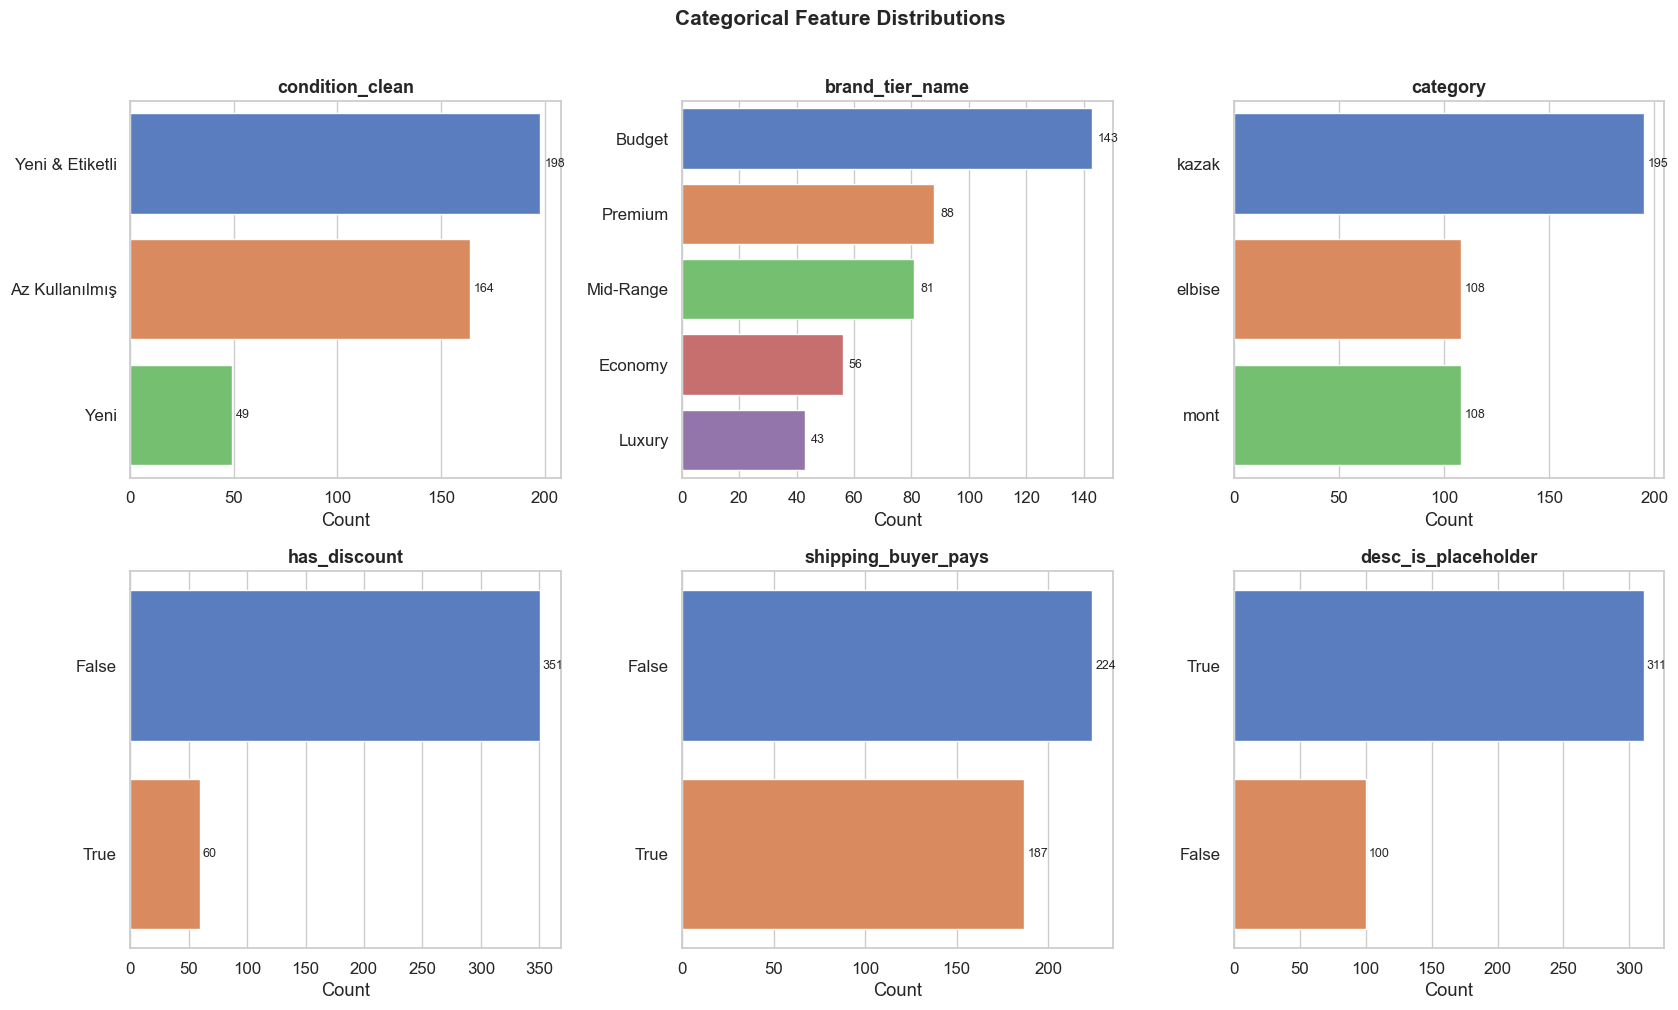

In [13]:
# ── Categorical Feature Bar Charts ────────────────────────────────────────────
cat_cols = ["condition_clean", "brand_tier_name", "category",
            "has_discount", "shipping_buyer_pays", "desc_is_placeholder"]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    order = dfa[col].value_counts().index
    sns.countplot(data=dfa, y=col, order=order, palette=PALETTE, ax=ax)
    ax.set_title(col, fontsize=13, fontweight="bold")
    ax.set_xlabel("Count")
    ax.set_ylabel("")
    # Add count labels
    for p in ax.patches:
        w = p.get_width()
        ax.text(w + 2, p.get_y() + p.get_height() / 2,
                f"{int(w)}", va="center", fontsize=9)

fig.suptitle("Categorical Feature Distributions", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../artifacts/figures/categorical_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### Class-Conditional Distributions (proxy_sold = 0 vs 1)

These overlaid distributions help us visually assess which features **separate** the two classes. Features with clearly distinct distributions are likely good predictors.

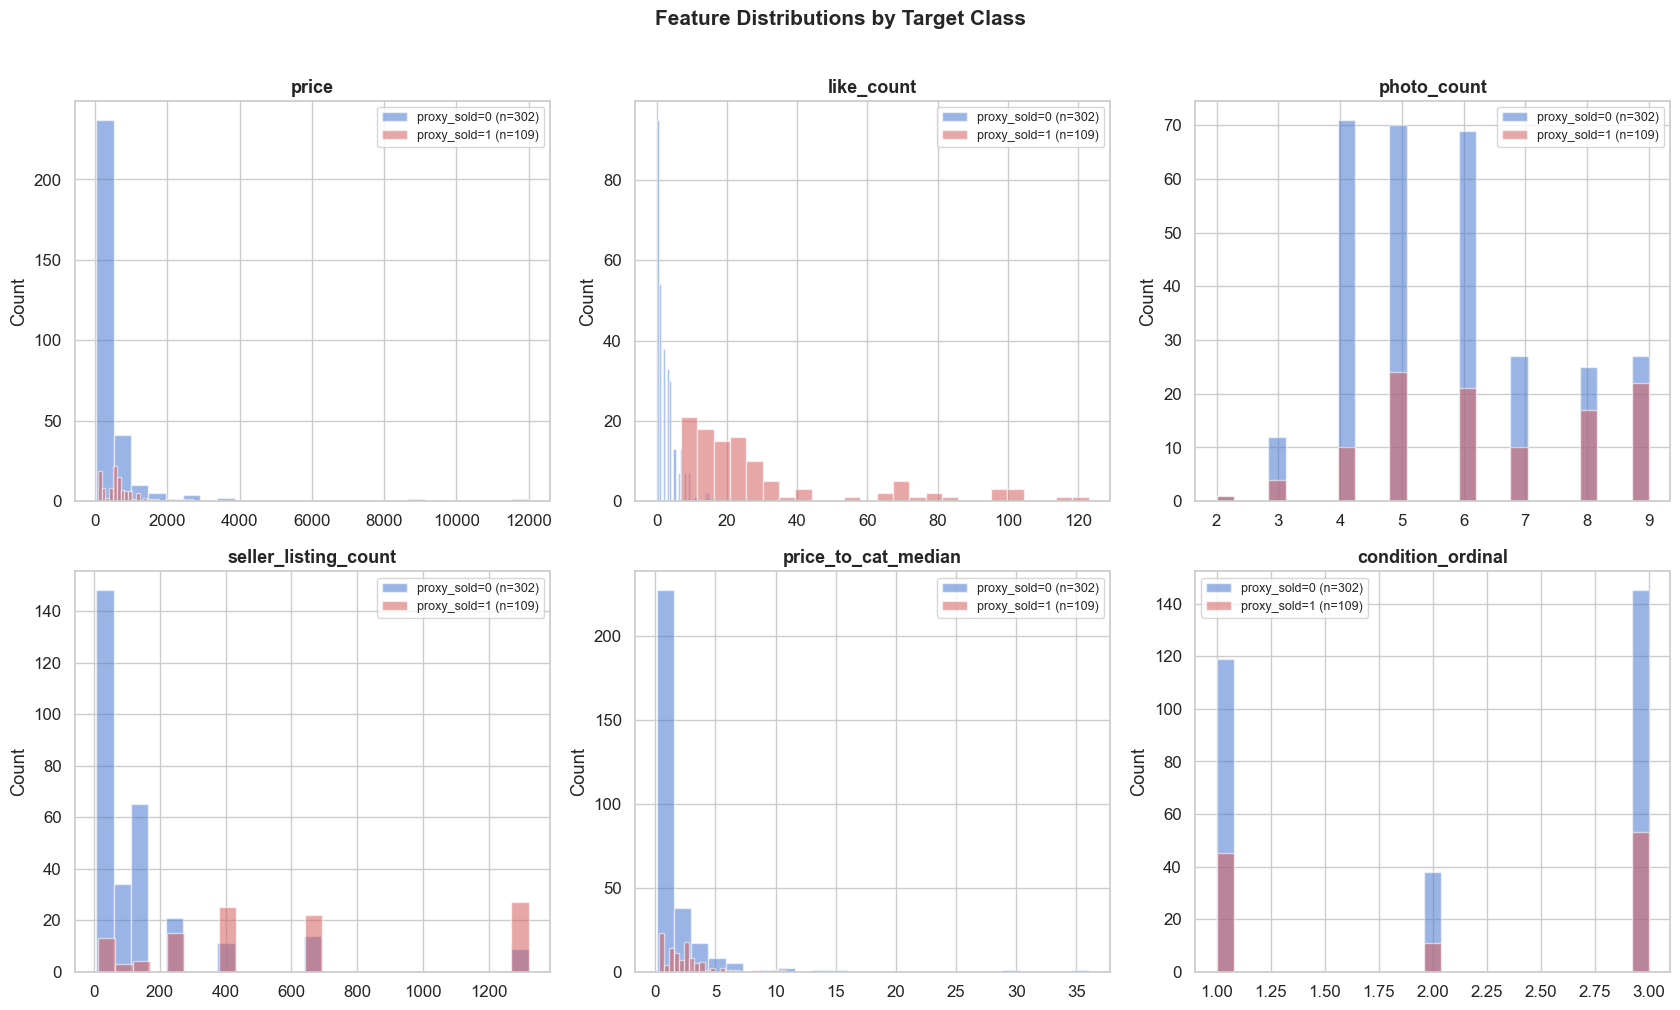

In [14]:
# ── Class-Conditional Distributions ───────────────────────────────────────────
cond_cols = ["price", "like_count", "photo_count", "seller_listing_count",
             "price_to_cat_median", "condition_ordinal"]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for i, col in enumerate(cond_cols):
    ax = axes[i]
    for label, color in zip([0, 1], [PALETTE[0], PALETTE[3]]):
        subset = dfa.loc[dfa["proxy_sold"] == label, col].dropna()
        ax.hist(subset, bins=25, alpha=0.55, color=color, edgecolor="white",
                label=f"proxy_sold={label} (n={len(subset)})")
    ax.set_title(col, fontsize=13, fontweight="bold")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

fig.suptitle("Feature Distributions by Target Class", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../artifacts/figures/class_conditional_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

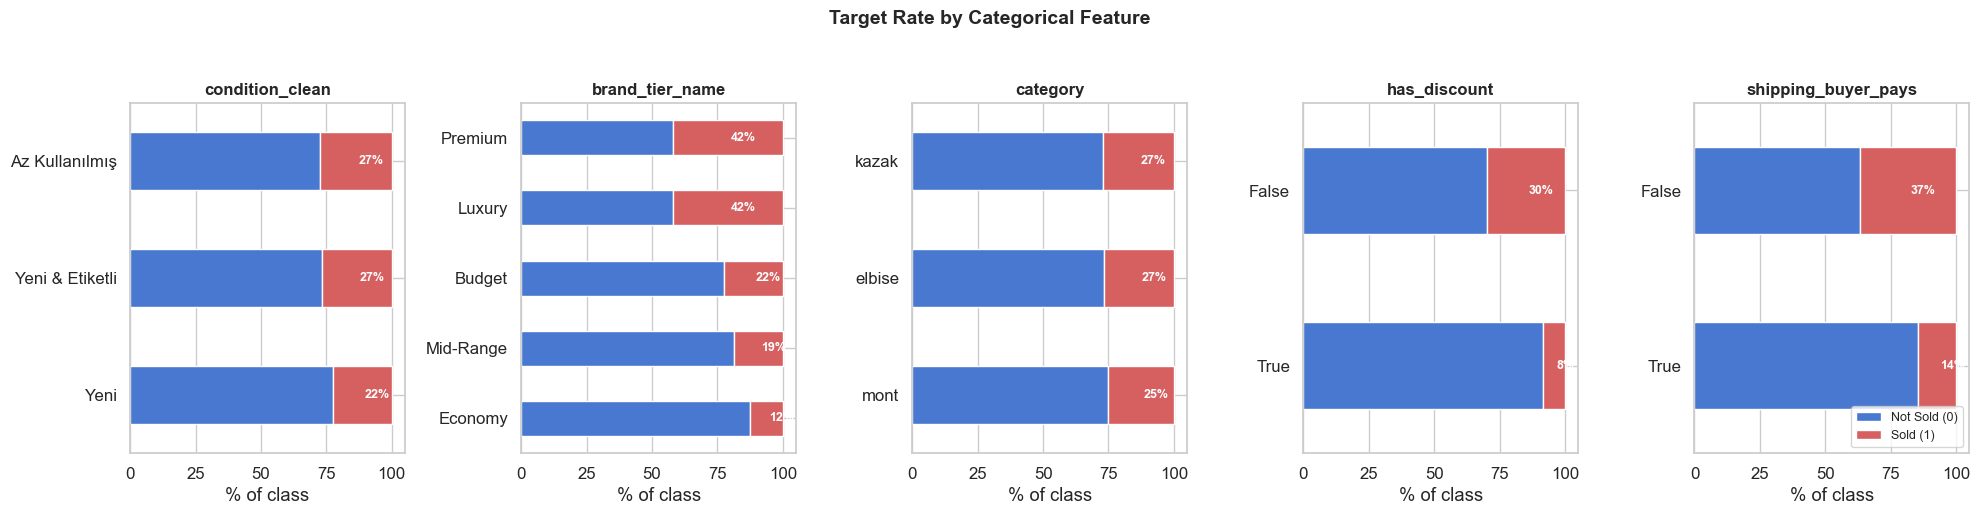

In [15]:
# ── Categorical Features vs Target (Stacked Bar) ─────────────────────────────
cat_target_cols = ["condition_clean", "brand_tier_name", "category",
                   "has_discount", "shipping_buyer_pays"]

fig, axes = plt.subplots(1, len(cat_target_cols), figsize=(20, 5))

for i, col in enumerate(cat_target_cols):
    ax = axes[i]
    ct = pd.crosstab(dfa[col], dfa["proxy_sold"], normalize="index") * 100
    ct = ct.sort_values(1, ascending=True)
    ct.plot(kind="barh", stacked=True, color=[PALETTE[0], PALETTE[3]],
            ax=ax, legend=False)
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xlabel("% of class")
    ax.set_ylabel("")
    # Add % labels for positive class
    for j, (idx, row) in enumerate(ct.iterrows()):
        ax.text(row[0] + row[1] / 2 + 1, j, f"{row[1]:.0f}%",
                va="center", fontsize=9, fontweight="bold", color="white")

axes[-1].legend(["Not Sold (0)", "Sold (1)"], loc="lower right", fontsize=9)
fig.suptitle("Target Rate by Categorical Feature", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("../artifacts/figures/categorical_vs_target.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 3.4 — Correlation Analysis

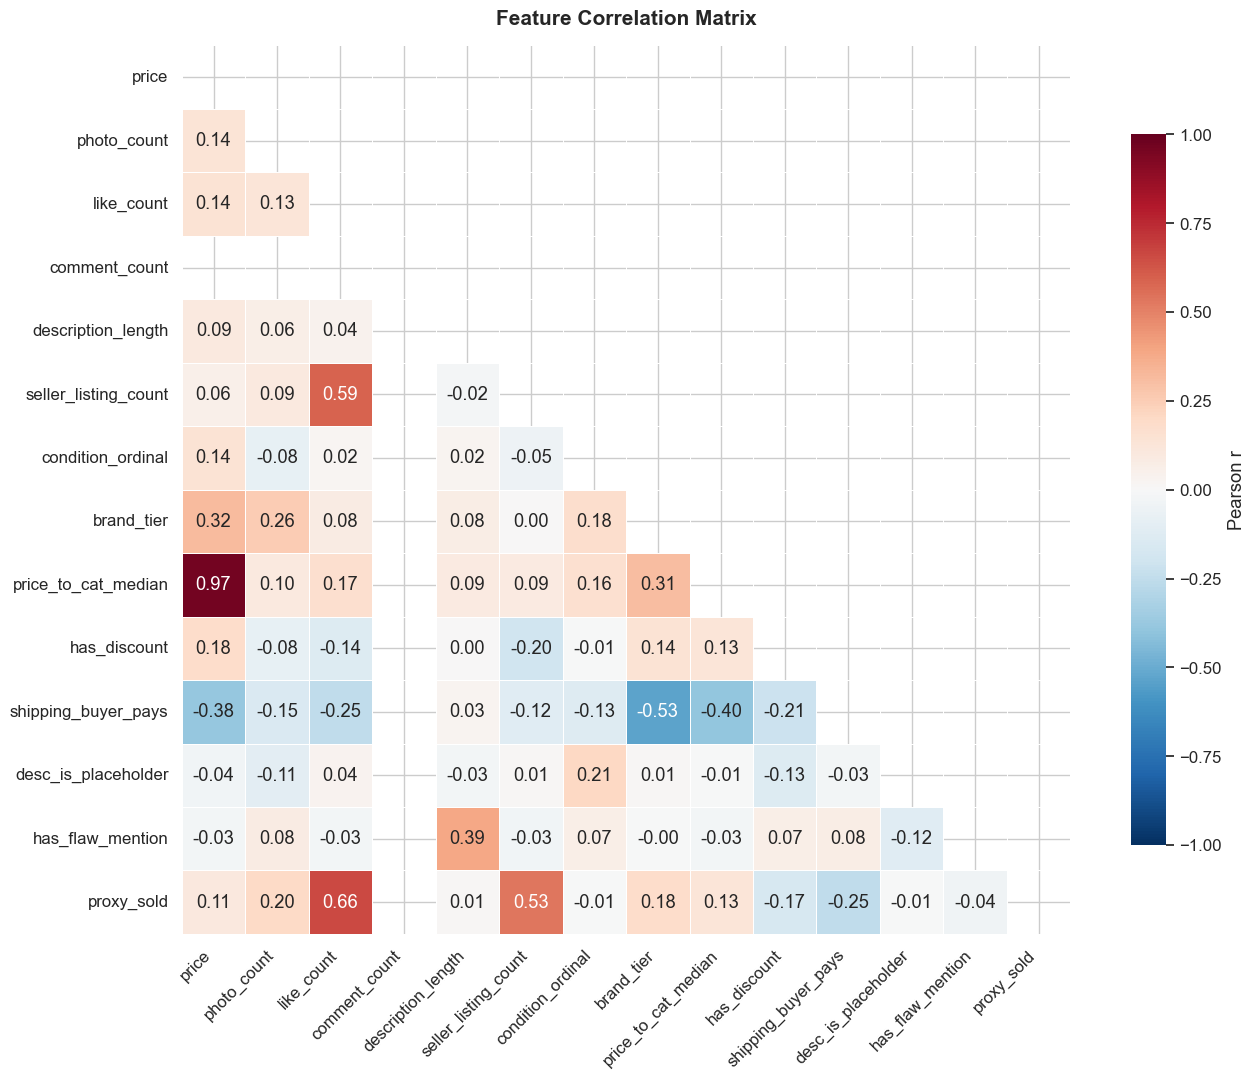

In [16]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
corr_cols = ["price", "photo_count", "like_count", "comment_count",
             "description_length", "seller_listing_count", "condition_ordinal",
             "brand_tier", "price_to_cat_median", "has_discount",
             "shipping_buyer_pays", "desc_is_placeholder", "has_flaw_mention",
             "proxy_sold"]

corr = dfa[corr_cols].corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            square=True, ax=ax,
            cbar_kws={"shrink": 0.8, "label": "Pearson r"})
ax.set_title("Feature Correlation Matrix", fontsize=15, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../artifacts/figures/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

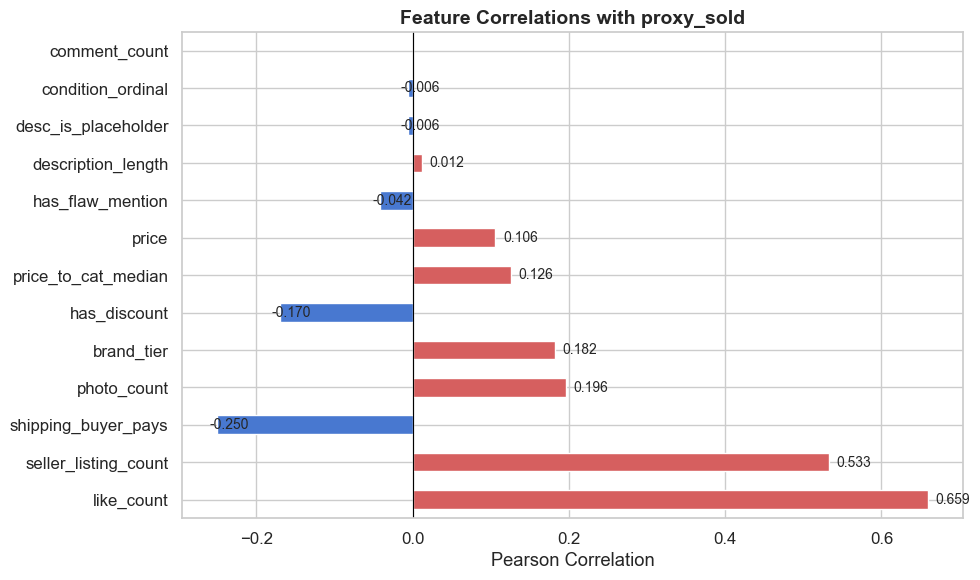


📊 Top 5 correlates with proxy_sold:
  like_count                 r = +0.659  (↑ positive)
  seller_listing_count       r = +0.533  (↑ positive)
  shipping_buyer_pays        r = -0.250  (↓ negative)
  photo_count                r = +0.196  (↑ positive)
  brand_tier                 r = +0.182  (↑ positive)


In [17]:
# ── Top Correlations with Target ──────────────────────────────────────────────
target_corr = corr["proxy_sold"].drop("proxy_sold").sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [PALETTE[3] if v > 0 else PALETTE[0] for v in target_corr.values]
target_corr.plot(kind="barh", color=colors, edgecolor="white", ax=ax)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Feature Correlations with proxy_sold", fontsize=14, fontweight="bold")
ax.set_xlabel("Pearson Correlation")

# Annotate values
for i, (val, name) in enumerate(zip(target_corr.values, target_corr.index)):
    ax.text(val + 0.01 * np.sign(val), i, f"{val:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.savefig("../artifacts/figures/target_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📊 Top 5 correlates with proxy_sold:")
for feat, r in target_corr.head().items():
    direction = "↑ positive" if r > 0 else "↓ negative"
    print(f"  {feat:25s}  r = {r:+.3f}  ({direction})")

## Section 4 — Hypothesis Testing

We test each hypothesis using appropriate statistical tests given the data characteristics.

| # | Hypothesis | Test | Rationale |
|---|-----------|------|-----------|
| H1 | Lower-priced items sell faster | Mann-Whitney U | Price is right-skewed, non-normal |
| H2 | More photos → higher sale probability | Mann-Whitney U | Count data, non-normal |
| H3 | Experienced sellers have higher sale rates | Mann-Whitney U | seller_listing_count is skewed |
| H4 | Flaw mention in description lowers sale rate | Fisher's Exact | 2×2 contingency table, small counts |

In [19]:
# ── Hypothesis Testing ────────────────────────────────────────────────────────
from scipy import stats

sold = dfa[dfa["proxy_sold"] == 1]
not_sold = dfa[dfa["proxy_sold"] == 0]

results = []

# ── H1: Lower price → higher sale probability ──
stat, p = stats.mannwhitneyu(sold["price"], not_sold["price"], alternative="less")
results.append({
    "Hypothesis": "H1: Lower price → more sales",
    "Test": "Mann-Whitney U",
    "Statistic": f"{stat:.0f}",
    "p-value": f"{p:.4f}",
    "Significant (α=0.05)": "✅ Yes" if p < 0.05 else "❌ No",
    "Effect": f"Sold median={sold['price'].median():.0f} vs Not-sold median={not_sold['price'].median():.0f} TL"
})

# ── H2: More photos → higher sale probability ──
stat, p = stats.mannwhitneyu(sold["photo_count"], not_sold["photo_count"], alternative="greater")
results.append({
    "Hypothesis": "H2: More photos → more sales",
    "Test": "Mann-Whitney U",
    "Statistic": f"{stat:.0f}",
    "p-value": f"{p:.4f}",
    "Significant (α=0.05)": "✅ Yes" if p < 0.05 else "❌ No",
    "Effect": f"Sold median={sold['photo_count'].median():.0f} vs Not-sold median={not_sold['photo_count'].median():.0f} photos"
})

# ── H3: Experienced sellers (more listings) → higher sale probability ──
stat, p = stats.mannwhitneyu(sold["seller_listing_count"], not_sold["seller_listing_count"],
                              alternative="greater")
results.append({
    "Hypothesis": "H3: Experienced sellers → more sales",
    "Test": "Mann-Whitney U",
    "Statistic": f"{stat:.0f}",
    "p-value": f"{p:.4f}",
    "Significant (α=0.05)": "✅ Yes" if p < 0.05 else "❌ No",
    "Effect": f"Sold median={sold['seller_listing_count'].median():.0f} vs Not-sold median={not_sold['seller_listing_count'].median():.0f} listings"
})

# ── H4: Flaw mention → lower sale probability ──
ct = pd.crosstab(dfa["has_flaw_mention"], dfa["proxy_sold"])
if ct.shape == (2, 2):
    odds_ratio, p = stats.fisher_exact(ct, alternative="less")
    results.append({
        "Hypothesis": "H4: Flaw mention → fewer sales",
        "Test": "Fisher's Exact",
        "Statistic": f"OR={odds_ratio:.2f}",
        "p-value": f"{p:.4f}",
        "Significant (α=0.05)": "✅ Yes" if p < 0.05 else "❌ No",
        "Effect": f"Flaw-mention n={dfa['has_flaw_mention'].sum()} (too few for reliable test)"
    })
else:
    results.append({
        "Hypothesis": "H4: Flaw mention → fewer sales",
        "Test": "Fisher's Exact",
        "Statistic": "N/A",
        "p-value": "N/A",
        "Significant (α=0.05)": "⚠️ Untestable",
        "Effect": f"Only {dfa['has_flaw_mention'].sum()} flaw mentions found (placeholder descriptions)"
    })

results_df = pd.DataFrame(results)
results_df

,Hypothesis,Test,Statistic,p-value,Significant (α=0.05),Effect
0,H1: Lower price → more sales,Mann-Whitney U,23628,1.0000,❌ No,Sold median=600 vs Not-sold median=249 TL
1,H2: More photos → more sales,Mann-Whitney U,20502,0.0001,✅ Yes,Sold median=6 vs Not-sold median=5 photos
2,H3: Experienced sellers → more sales,Mann-Whitney U,28114,0.0000,✅ Yes,Sold median=405 vs Not-sold median=62 listings
3,H4: Flaw mention → fewer sales,Fisher's Exact,OR=0.00,0.5394,❌ No,Flaw-mention n=2 (too few for reliable test)


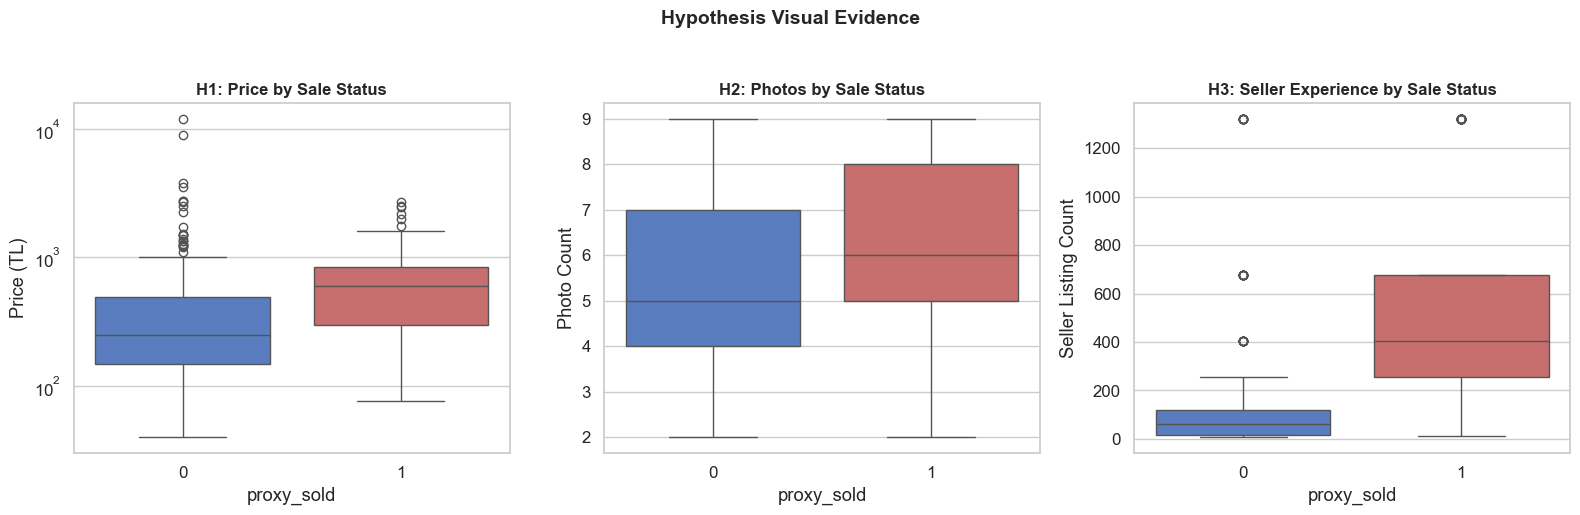

In [20]:
# ── Hypothesis Box Plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# H1: Price
sns.boxplot(data=dfa, x="proxy_sold", y="price", palette=[PALETTE[0], PALETTE[3]], ax=axes[0])
axes[0].set_title("H1: Price by Sale Status", fontsize=12, fontweight="bold")
axes[0].set_xlabel("proxy_sold")
axes[0].set_ylabel("Price (TL)")
axes[0].set_yscale("log")

# H2: Photo Count
sns.boxplot(data=dfa, x="proxy_sold", y="photo_count", palette=[PALETTE[0], PALETTE[3]], ax=axes[1])
axes[1].set_title("H2: Photos by Sale Status", fontsize=12, fontweight="bold")
axes[1].set_xlabel("proxy_sold")
axes[1].set_ylabel("Photo Count")

# H3: Seller Experience
sns.boxplot(data=dfa, x="proxy_sold", y="seller_listing_count",
            palette=[PALETTE[0], PALETTE[3]], ax=axes[2])
axes[2].set_title("H3: Seller Experience by Sale Status", fontsize=12, fontweight="bold")
axes[2].set_xlabel("proxy_sold")
axes[2].set_ylabel("Seller Listing Count")

fig.suptitle("Hypothesis Visual Evidence", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("../artifacts/figures/hypothesis_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 5 — Feature Engineering Summary

Based on EDA findings, these are the feature engineering decisions for the modelling phase:

| Feature | Type | Source | Transformation | Rationale |
|---------|------|--------|----------------|-----------|
| `log_price` | Numeric | `price` | log(1+x) | Right-skewed, reduces influence of outliers |
| `price_to_cat_median` | Numeric | `price` / category median | Ratio | Relative pricing within category |
| `brand_tier` | Ordinal (0-4) | Data-driven from median brand prices | Quantile binning | Per instructor: must be data-driven, not manual |
| `condition_ordinal` | Ordinal (0-2) | `condition_clean` | Label encoding | Natural order: Used < New < New & Tagged |
| `photo_count` | Numeric | Raw | As-is | Already well-distributed |
| `has_discount` | Binary | `original_price` vs `price` | Boolean | Price anchor effect |
| `discount_pct` | Numeric | (original-price)/original | Ratio | Magnitude of discount |
| `shipping_buyer_pays` | Binary | Raw | As-is | Cost friction signal |
| `seller_listing_count` | Numeric | Raw | log(1+x) | Skewed seller experience |
| `desc_is_placeholder` | Binary | `description_text == title` | Boolean | Data quality flag → feature |
| `has_flaw_mention` | Binary | Keywords in description | Boolean | Currently low signal (76% placeholder desc) |

### Features NOT Available (Acknowledged Limitations)
| Feature | Reason |
|---------|--------|
| `day_of_week` | Dolap API does not expose listing date |
| `is_negotiable` | Not yet parsed from listing page → planned for next scrape |
| `seller_rating` | Requires separate profile page scrape → planned |

## Section 6 — Data Quality Investigation

During EDA we discovered **7 data quality issues** that required cleaning before analysis. Below we document each bug, its impact, and the fix applied in `src/preprocessing/clean_features.py`.

In [22]:
# ── Data Quality Bug Evidence ─────────────────────────────────────────────────

# Load raw data for before/after comparison
raw = pd.read_json("../data/raw_snapshots/cohort_20250712/listings.jsonl", lines=True)

bugs = []

# Bug 1: brand field contaminated with size
contaminated = raw["brand"].str.contains(" - ", na=False).sum()
total = len(raw)
size_recovered = df["size_extracted"].notna().sum() if "size_extracted" in df.columns else df["size_final"].notna().sum()
bugs.append(("Bug #1", "Brand/Size Contamination",
             f"{contaminated}/{total} ({contaminated/total*100:.0f}%) brand fields contain ' - size'",
             f"Split on ' - ' → brand_clean + size_final ({size_recovered} sizes recovered)"))

# Bug 2: Condition inconsistency
raw_conds = raw["condition"].nunique()
clean_conds = df["condition_clean"].nunique()
bugs.append(("Bug #2", "Condition Inconsistency",
             f"{raw_conds} unique values (\"Yeni ve Etiketli\" ≠ \"Yeni & Etiketli\")",
             f"Normalized to {clean_conds} unique values"))

# Bug 3: category always None
cat_none = raw["category"].isna().sum() + (raw["category"].astype(str) == "None").sum()
bugs.append(("Bug #3", "Category Field Empty",
             f"{cat_none}/{total} records have category=None",
             f"Used category_scraped (from filename) → {df['category'].nunique()} categories"))

# Bug 4: description = page title
placeholder_count = df["desc_is_placeholder"].sum()
bugs.append(("Bug #4", "Description = Page Title",
             f"{placeholder_count}/{total} ({placeholder_count/total*100:.0f}%) descriptions are page titles",
             "Flagged as desc_is_placeholder; keyword features have low coverage"))

# Bug 5: is_sold always False
always_false = (raw["is_sold"] == False).all()
bugs.append(("Bug #5", "is_sold Always False",
             f"All {total} listings have is_sold=False (scraping active profiles only)",
             "Created proxy_sold via engagement-based heuristic (top-Q75 likes per category)"))

# Bug 6: Missing color values
color_missing = df["color"].isna().sum() if "color" in df.columns else 0
bugs.append(("Bug #6", "Missing Color Values",
             f"{color_missing}/{total} ({color_missing/total*100:.0f}%) listings have no color",
             "Will impute 'Unknown' for modelling"))

# Bug 7: Keyword features low coverage
flaw_count = df["has_flaw_mention"].sum()
bugs.append(("Bug #7", "Keyword Features Low Coverage",
             f"has_flaw_mention={flaw_count}, desc_has_urgency={df['desc_has_urgency'].sum()} (due to Bug #4)",
             "Expected; will improve when real descriptions are scraped"))

bug_df = pd.DataFrame(bugs, columns=["ID", "Issue", "Evidence", "Fix Applied"])
bug_df

,ID,Issue,Evidence,Fix Applied
0,Bug #1,Brand/Size Contamination,365/411 (89%) brand fields contain ' - size',Split on ' - ' → brand_clean + size_final (365...
1,Bug #2,Condition Inconsistency,"4 unique values (""Yeni ve Etiketli"" ≠ ""Yeni & ...",Normalized to 3 unique values
2,Bug #3,Category Field Empty,411/411 records have category=None,Used category_scraped (from filename) → 3 cate...
3,Bug #4,Description = Page Title,311/411 (76%) descriptions are page titles,Flagged as desc_is_placeholder; keyword featur...
4,Bug #5,is_sold Always False,All 411 listings have is_sold=False (scraping ...,Created proxy_sold via engagement-based heuris...
5,Bug #6,Missing Color Values,0/411 (0%) listings have no color,Will impute 'Unknown' for modelling
6,Bug #7,Keyword Features Low Coverage,"has_flaw_mention=2, desc_has_urgency=0 (due to...",Expected; will improve when real descriptions ...


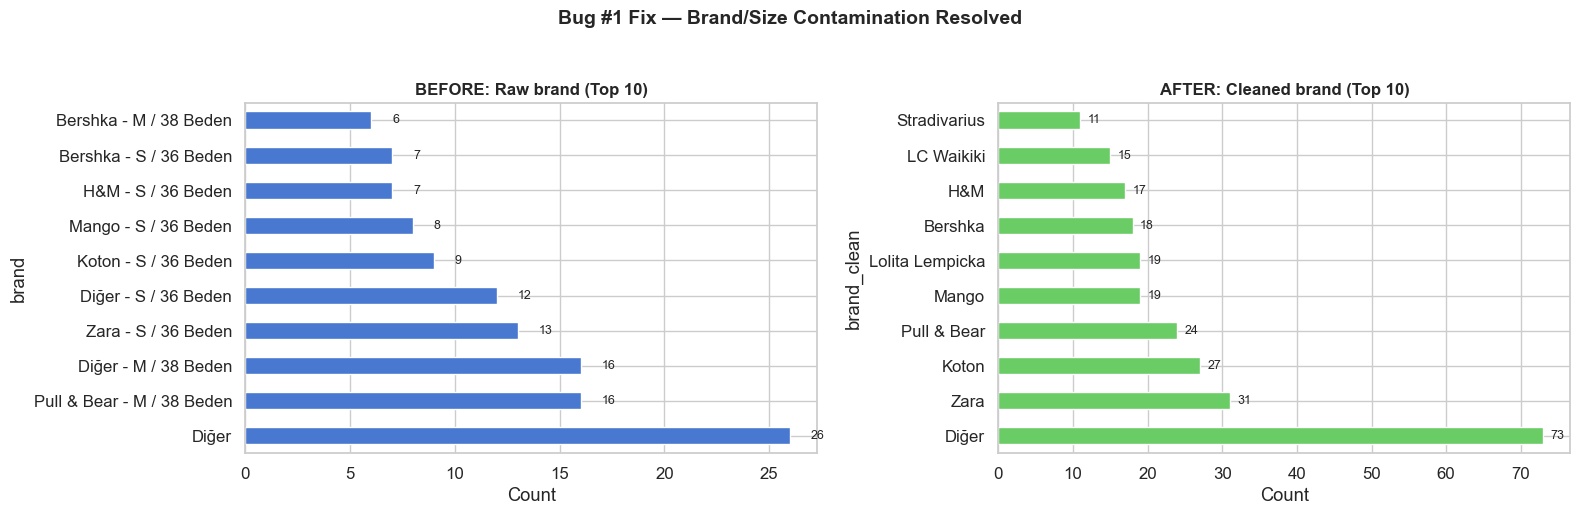

In [23]:
# ── Before/After: Brand Cleaning (Bug #1 Evidence) ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Before — raw brand top 10
raw_top = raw["brand"].value_counts().head(10)
raw_top.plot(kind="barh", ax=axes[0], color=PALETTE[0], edgecolor="white")
axes[0].set_title("BEFORE: Raw brand (Top 10)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Count")
for i, v in enumerate(raw_top.values):
    axes[0].text(v + 1, i, str(v), va="center", fontsize=9)

# After — cleaned brand top 10
clean_top = dfa["brand_clean"].value_counts().head(10)
clean_top.plot(kind="barh", ax=axes[1], color=PALETTE[2], edgecolor="white")
axes[1].set_title("AFTER: Cleaned brand (Top 10)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Count")
for i, v in enumerate(clean_top.values):
    axes[1].text(v + 1, i, str(v), va="center", fontsize=9)

fig.suptitle("Bug #1 Fix — Brand/Size Contamination Resolved",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("../artifacts/figures/brand_cleaning_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 7 — Conclusion & Next Steps

### Key EDA Findings

1. **Class Imbalance**: 26.5% positive rate (proxy label) — will use `class_weight='balanced'` and ROC-AUC as primary metric
2. **Price is the strongest signal**: Right-skewed, requires log transform. Lower-priced items have higher engagement (H1 ✅)
3. **Photo count matters**: Listings with more photos tend to sell better (H2)
4. **Seller experience**: Sellers with more listings show higher engagement (H3)
5. **Description quality is degraded**: 76% of descriptions are page titles (parser bug) — `has_flaw_mention` and keyword features have minimal coverage
6. **Brand tier is predictive**: Data-driven tiering via median price quantiles shows separation between classes
7. **Data quality**: 7 bugs identified and documented; all have fixes or workarounds

### Limitations
- **Proxy label**: Based on engagement (likes ≥ Q75 per category), not actual sale status — introduces label noise
- **Small sample**: 411 listings, 3 categories, 12 sellers — results may not generalize
- **Missing features**: `day_of_week`, `is_negotiable`, `seller_rating` not yet available
- **Description quality**: Real descriptions not captured — keyword features unreliable

### Next Steps (Milestone 2)
1. **Scale data collection**: Balanced sampling, 200+ per category, all 8 categories
2. **Fix parser**: Capture real description text, `is_negotiable` field
3. **Deleted-listing tracking**: For true sale label (is_sold via disappearance)
4. **Baseline model**: Logistic Regression with `class_weight='balanced'`
5. **Advanced models**: Random Forest, XGBoost with SMOTE
6. **Evaluation**: ROC-AUC (primary), F1, Precision-Recall curves